## Comparing La Nina and ACCESS-S2 forecasts for falling below median rainfall anomalies

In [1]:
# Imports
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib import cm, colors
from matplotlib.colors import LinearSegmentedColormap
import sys
sys.path.insert(0,'/home/548/pag548/code/CSIRO_ENSO/config')
sys.path.insert(0,'/home/548/pag548/code/CSIRO_ENSO/src')
import categorical_enso_functions as func
from config import ENS_LIST, CALIBRATED_PR_DIR, YEAR_RANGE, OUT_PATH


In [2]:
import warnings
warnings.simplefilter("ignore", RuntimeWarning)

In [3]:
def format_gridlines(ax, top_labels=False, bottom_labels=False, left_labels=False, right_labels=False):
    
    import cartopy.crs as ccrs
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.75, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = top_labels
    gl.bottom_labels = bottom_labels
    gl.right_labels = right_labels
    gl.left_labels = left_labels
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

In [4]:
# ENSO years
EN = [1963, 1965, 1968, 1969, 1972, 1976, 1977, 1979, 1982, 1986, 1987, 1991, 1994, 1997, 2002, 
      2004, 2006, 2009, 2014, 2015, 2018]

LN = [1964, 1966, 1967, 1970, 1971, 1973, 1974, 1975, 1983, 1984, 1988, 1995, 1996, 1998, 1999, 
      2000, 2005, 2007, 2010, 2011, 2017, 2020, 2021, 2022]

NN = [1960, 1961, 1962, 1978, 1980, 1981, 1985, 1989, 1990, 1992, 1993, 2001, 2003, 2008, 2012, 
      2013, 2016, 2019]

## AGCD

In [5]:
# AGCD landmask
landmask = xr.open_dataset('/g/data/w40/asp561/agcd/mask_australia_0.05deg.nc').landmask

In [6]:
# AGCD data (v2 for precip) 
file_pattern = "/g/data/zv2/agcd/v2-0-2/precip/total/r005/01month/agcd_v2_precip_total_r005_monthly_{}.nc"
# Generate list of file paths for years 1960-2022
years = range(1960, 2023)  
paths = [file_pattern.format(year) for year in years]
# Open dataset 
precip = xr.open_mfdataset(paths, combine='nested', concat_dim='time', chunks={'time':12, 'lat':'auto', 'lon':'auto'}).precip

In [7]:
# Taget La Nina years 
target_years = [1983, 1984, 1988, 1995, 1996, 1998, 1999, 2000, 2005, 2007, 2010, 2011, 2017]

In [8]:
def spatial_probability_deficit(cdf, anom_data, threshold):
    P = xr.apply_ufunc(
        func.get_probability_deficit, cdf, anom_data, threshold,
        input_core_dims=[["year"], ["year"], []],  # Match time dimension
        output_core_dims=[[]],  # Remove time dim
        vectorize=True,
        dask="parallelized"
    )
    return P

In [9]:
climatologies = []
rainfall_quantiles = []
LN_probabilities = []
target_anomalies = []


for target_year in target_years:
    
    end_year = target_year - 1
    precip_target = precip.sel(time=f"{target_year}")
    precip_clim = precip.sel(time=slice(None, f"{end_year}-12"))

    clim_son = precip_clim.sel(time=precip_clim.time.dt.season == "SON").groupby("time.year").mean("time").mean("year")
    anom_son = precip_clim.sel(time=precip_clim.time.dt.season == "SON").groupby("time.year").mean("time") - clim_son
    anom_son = anom_son.where(landmask.data == 1)

    anom_son_LN = anom_son.sel(year=anom_son['year'].isin(LN)).chunk(chunks={'year': -1, 'lat': -1, 'lon': -1})
    
    q33_rainfall = anom_son.quantile(0.5, dim='year').chunk(chunks={'lat':-1, 'lon':-1})

    sorted_LN, cdf_LN = xr.apply_ufunc(
    func.empirical_cdf, 
    anom_son_LN, 
    input_core_dims=[["year"]],
    output_core_dims=[["year"], ["year"]], 
    vectorize=True,
    dask="parallelized"
    )

    P_LN_33th = spatial_probability_deficit(cdf_LN, anom_son_LN, q33_rainfall)

    anom_target = precip_target.sel(time=precip_target.time.dt.season == "SON").mean("time") - clim_son
    anom_target = anom_target.where(landmask.data == 1)

    climatologies.append(clim_son)
    rainfall_quantiles.append(q33_rainfall)
    LN_probabilities.append(P_LN_33th)
    target_anomalies.append(anom_target)

In [10]:
climatologies = xr.concat(climatologies, dim="year").assign_coords(year=target_years)
rainfall_quantiles = xr.concat(rainfall_quantiles, dim="year").assign_coords(year=target_years)
LN_probabilities = xr.concat(LN_probabilities, dim="year").assign_coords(year=target_years)
target_anomalies = xr.concat(target_anomalies, dim="year").assign_coords(year=target_years)

## ACCESS-S2

In [11]:
# Function to compute all lead times
LEAD_DICT = {0 : '0901', 
             1 : '0801',
             2 : '0701',
             3 : '0601',
             4 : '0501',
             5 : '0401',
             6 : '0301',
             7 : '0201'}

diff_maps = {}
brier_LN_results = {}
brier_lead_results = {}

def analyse_access(leadtime):
    """
    Compute ACCESS hindcast anomalies for every target year and then compute Brier Skill Scores
    """

    target_anoms = []
    below_q33 = []

    # Load the hindcast leadtime data from disk
    filename = LEAD_DICT[leadtime]+'.nc'
    ds = xr.load_dataarray( OUT_PATH / filename, chunks={'year' : 38})

    print(f'Loading {OUT_PATH / filename}')
    
    # Convert to mm per month and chunk 
    son_yearly = (ds * 30.33).chunk('auto')

    for target_year in target_years:
        son_target_anom = son_yearly.sel(year=target_year) - climatologies.sel(year=target_year)
        below = (son_target_anom < rainfall_quantiles.sel(year=target_year)).sum(dim="ens") / son_target_anom.ens.size
        target_anoms.append(son_target_anom)
        below_q33.append(below)

        print(f'Computed anomalies for {target_year} for leadtime {leadtime}')
    
    target_anoms_da = xr.concat(target_anoms, dim="year").assign_coords(year=target_years)
    below_q33_da = xr.concat(below_q33, dim="year").assign_coords(year=target_years) 

    brier_LN_means = []
    brier_lead_means = []
    diff_lead_maps = []

    for year in target_years:
        LN_prob = LN_probabilities.sel(year=year).where(landmask.data == 1)
        below_lead = below_q33_da.sel(year=year).where(landmask.data == 1)
        anom_target = target_anomalies.sel(year=year)
        q33_rainfall = rainfall_quantiles.sel(year=year)

        obs_binary = (anom_target < q33_rainfall).astype(int)

        brier_score_LN = ((LN_prob - obs_binary) ** 2)
        brier_score_lead = ((below_lead - obs_binary) ** 2)

        #diff_lead_maps.append(brier_score_EN - brier_score_lead)

        brier_LN_means.append(brier_score_LN.mean(dim=['lat', 'lon']).values)
        brier_lead_means.append(brier_score_lead.mean(dim=['lat', 'lon']).values)

        print(f'Computed BSS for {year} for leadtime {leadtime}')
    
    #diff_lead_maps = xr.concat(diff_lead_maps, dim="year").assign_coords(year=target_years)
    brier_LN_means = np.array(brier_LN_means)
    brier_lead_means = np.array(brier_lead_means)

    #return diff_lead_maps, brier_EN_means, brier_lead_means
    return brier_LN_means, brier_lead_means

In [12]:
# Compute the rest of the leadtimes
for lead in range(0,8):
    #diff_maps[lead], brier_EN_results[lead], brier_lead_results[lead] =  analyse_access(lead)
    brier_LN_results[lead], brier_lead_results[lead] =  analyse_access(lead)

Loading /g/data/gb02/pag548/CSIRO_ENSO/0901.nc
Computed anomalies for 1983 for leadtime 0
Computed anomalies for 1984 for leadtime 0
Computed anomalies for 1988 for leadtime 0
Computed anomalies for 1995 for leadtime 0
Computed anomalies for 1996 for leadtime 0
Computed anomalies for 1998 for leadtime 0
Computed anomalies for 1999 for leadtime 0
Computed anomalies for 2000 for leadtime 0
Computed anomalies for 2005 for leadtime 0
Computed anomalies for 2007 for leadtime 0
Computed anomalies for 2010 for leadtime 0
Computed anomalies for 2011 for leadtime 0
Computed anomalies for 2017 for leadtime 0
Computed BSS for 1983 for leadtime 0
Computed BSS for 1984 for leadtime 0
Computed BSS for 1988 for leadtime 0
Computed BSS for 1995 for leadtime 0
Computed BSS for 1996 for leadtime 0
Computed BSS for 1998 for leadtime 0
Computed BSS for 1999 for leadtime 0
Computed BSS for 2000 for leadtime 0
Computed BSS for 2005 for leadtime 0
Computed BSS for 2007 for leadtime 0
Computed BSS for 2010 fo

In [14]:
cmap = LinearSegmentedColormap.from_list("pink_green", ["#e7298a", "white", "#66a61e"])

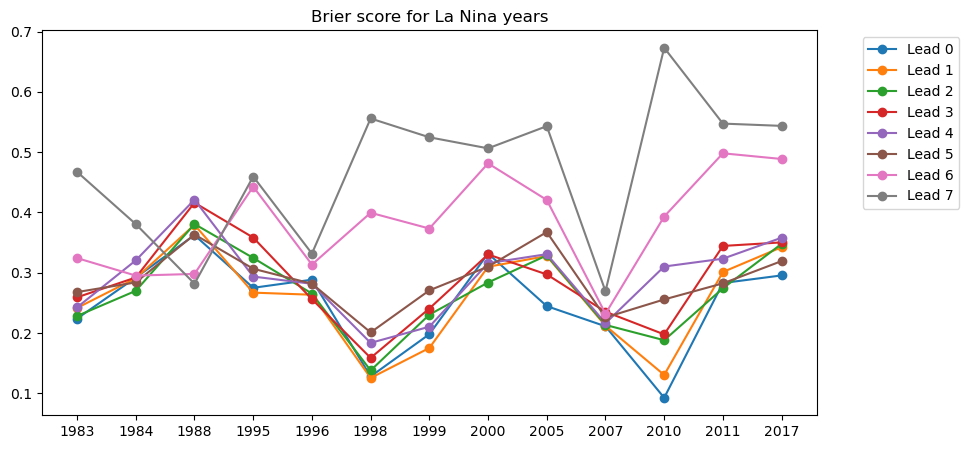

In [15]:
brier_x = np.arange(1,14,1)

plt.figure(figsize=(10, 5))

for lead in range(0,8):
    label = f'Lead {lead}'
    color = cmap(lead/7.0)
    plt.plot(brier_x, brier_lead_results[lead], marker='o', label=label)  # Dark Green

plt.title('Brier score for La Nina years')

plt.xticks(brier_x, target_years)
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

In [16]:
for key in brier_lead_results.keys():
    print (f'Lead {key} mean BSS = {brier_lead_results[key].mean():.3f}')

Lead 0 mean BSS = 0.248
Lead 1 mean BSS = 0.259
Lead 2 mean BSS = 0.267
Lead 3 mean BSS = 0.287
Lead 4 mean BSS = 0.293
Lead 5 mean BSS = 0.287
Lead 6 mean BSS = 0.382
Lead 7 mean BSS = 0.468


In [17]:
import pandas as pd

In [18]:
df = pd.DataFrame.from_dict(brier_lead_results)

In [19]:
df.to_csv('/home/548/pag548/code/CSIRO_ENSO/Forecasting/LN_q33_BSS.txt')

In [20]:
df

,0,1,2,3,4,5,6,7
0,0.223871,0.241581,0.228213,0.259181,0.242538,0.267887,0.324231,0.467252
1,0.291991,0.290801,0.269948,0.292073,0.320489,0.283889,0.295187,0.380590
2,0.362376,0.379425,0.380726,0.416127,0.421100,0.363369,0.297995,0.281753
3,0.274972,0.266952,0.324475,0.358266,0.293596,0.306568,0.442811,0.459559
4,0.288402,0.263455,0.265378,0.256116,0.281591,0.281738,0.313471,0.331729
5,0.127931,0.125383,0.137836,0.158666,0.183568,0.200955,0.399421,0.555836
6,0.197993,0.175124,0.230419,0.240597,0.210415,0.270699,0.373286,0.524633
7,0.331800,0.309847,0.283742,0.330314,0.315782,0.310038,0.481390,0.506307
8,0.244564,0.327708,0.328709,0.297158,0.330757,0.367416,0.420696,0.543095
9,0.211097,0.211940,0.213370,0.235247,0.216156,0.225755,0.232004,0.269226
